# Eksperimen Tesis: SAC-Based Gamma Controller untuk Optimasi Portofolio Berbasis Network
## Perbandingan Strategi Proposed vs Benchmark Industri

**Peneliti:** [Nama Anda]
**Tujuan:** Mengevaluasi efektivitas reinforcement learning (Soft Actor-Critic) dalam mengontrol parameter regularisasi network (Gamma) pada model Markowitz yang difilter dengan Random Matrix Theory (RMT) dan Minimum Spanning Tree (MST).

**Metodologi:**
1. **Proposed:** SAC mengontrol Gamma secara dinamis berdasarkan fitur network (centrality, density, MST distance).
2. **Baselines:** Equal-Weight, Buy-and-Hold, Classic Markowitz, dan Static Gamma (0.0, 1.0, 2.0).
3. **Ablation Study:** Leave-One-Out (LOO) untuk mengevaluasi kontribusi setiap fitur network terhadap performa agen RL.

# Ablation Study: Feature Selection for SAC-Based Gamma Controller
## Evaluasi dengan 4 Metrik: Sharpe Ratio, Sortino Ratio, Calmar Ratio, CVaR (95%)
### Versi OPTIMASI — Perbaikan bottleneck performa

**Optimasi yang dilakukan:**
| # | Masalah | Fix |
|---|---------|-----|
| 1 | `learning_starts=200 > TRAIN_STEPS=100` — SAC tidak pernah belajar | `learning_starts=50`, `TRAIN_STEPS=1000` |
| 2 | Precompute RMT+MST diulang 8x per config | **Global cache** — hitung sekali, pakai semua config |
| 3 | `eigenvector_centrality(max_iter=2000)` — lambat | `max_iter=300`, fallback ke `degree_centrality` |
| 4 | Phase 4 loop redundant (ulang hitung fitur untuk visualisasi) | Pakai data dari global cache |
| 5 | MST dibangun 2x di `compute_network_features` | Bangun MST sekali, reuse untuk `mst_dist` |
| 6 | `run_backtest` panggil `get_centrality_weights` (RMT+MST lagi) | Gunakan `fast_centrality_weights` dari cache |

## Setup & Install

In [74]:
#%pip install stable_baselines3[extra]

## Global Settings & Imports

In [75]:
# ================================================================
# GLOBAL SETTINGS
# ================================================================
# Multi-seed for statistical robustness
SEEDS         = [42] #, 123, 77]          # [42, 123, 77] untuk multi-seed
TRAIN_STEPS   = 500               # OPT-FIX 1: naik dari 100 → 1000 (SAC butuh minimal ~500 steps untuk mulai belajar)
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20                 # sliding window untuk Calmar Ratio reward
CVAR_LEVEL    = 0.95               # confidence level CVaR

# Definisi eksperimen ablation
ABLATION_CONFIGS = {
    # --- Baseline: Static Gamma (Full Network Features) ---
    'Comp_Static_Gamma0'      : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1'      : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2'      : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},

    # --- Proposed: E2_NoMarket (Full Network Features, SAC Dynamic) ---
    'E2_NoMarket'             : {'use_network': True,  'use_market': False, 'extra_features': []},

    # --- Ablation E2: Leave-One-Out (Drop 1 Network Feature) ---
    'E2_drop_CentStd'         : {'use_network': True,  'use_market': False, 'extra_features': [], 'drop_nw_idx': 0},
    'E2_drop_CentMean'        : {'use_network': True,  'use_market': False, 'extra_features': [], 'drop_nw_idx': 1},
    'E2_drop_MSTDist'         : {'use_network': True,  'use_market': False, 'extra_features': [], 'drop_nw_idx': 2},
    'E2_drop_MaxCent'         : {'use_network': True,  'use_market': False, 'extra_features': [], 'drop_nw_idx': 3},
    'E2_drop_NetDens'         : {'use_network': True,  'use_market': False, 'extra_features': [], 'drop_nw_idx': 4},
}


# Mapping experiment ID to formal thesis names
THESIS_LABELS = {'Comp_Static_Gamma0': 'Static Gamma = 0.0', 'Comp_Static_Gamma1': 'Static Gamma = 1.0', 'Comp_Static_Gamma2': 'Static Gamma = 2.0', 'E2_NoMarket': 'Proposed (SAC + Network)', 'E2_drop_CentStd': 'Ablation: Drop Cent.Std', 'E2_drop_CentMean': 'Ablation: Drop Cent.Mean', 'E2_drop_MSTDist': 'Ablation: Drop MST.Dist', 'E2_drop_MaxCent': 'Ablation: Drop Max.Cent', 'E2_drop_NetDens': 'Ablation: Drop Net.Density', 'EW': 'Equal-Weight', 'B&H': 'Buy-and-Hold', 'Classic-MV': 'Classic Markowitz'}
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('ablation_results_4metrics', exist_ok=True)

print('Libraries loaded.')
print(f'Ablation configs: {list(ABLATION_CONFIGS.keys())}')
print(f'CVaR confidence level: {CVAR_LEVEL*100:.0f}%')
print(f'TRAIN_STEPS={TRAIN_STEPS} | SEEDS={SEEDS}')

Libraries loaded.
Ablation configs: ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2', 'E2_NoMarket', 'E2_drop_CentStd', 'E2_drop_CentMean', 'E2_drop_MSTDist', 'E2_drop_MaxCent', 'E2_drop_NetDens']
CVaR confidence level: 95%
TRAIN_STEPS=500 | SEEDS=[42]


## Phase 1: Data Preparation

In [76]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

Fungsi inti portofolio + **4 metrik evaluasi tesis** + **helper visualisasi**.

> **OPT-FIX 2 & 3:** `_build_mst_centrality` menggunakan `max_iter=300` (turun dari 2000).
> MST hanya dibangun **sekali** per window — tidak lagi 2x di `compute_network_features`.

In [77]:
# ────────────────────────────────────────────────────────────────
# 2A. Portfolio Optimization
# ────────────────────────────────────────────────────────────────

def apply_rmt_filter(returns_window):
    """Random Matrix Theory filter untuk denoising matriks korelasi."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """Solver SLSQP dengan constraint return >= mean(mu). Fallback ke equal-weight jika infeasible."""
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 0.4) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


def _build_mst_centrality(N, corr_f):
    """Bangun MST dan hitung eigenvector centrality dari matriks korelasi.
    
    OPT-FIX 3: max_iter turun 2000 → 300. Jika tidak konvergen, langsung fallback
    ke degree_centrality (lebih cepat, cukup baik sebagai proxy).
    """
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)  # OPT-FIX 3
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec


def get_centrality_weights(returns_window, gamma=1.0):
    """Hitung bobot portofolio berbasis centrality MST + Markowitz (full recompute)."""
    T, N = returns_window.shape
    mu     = returns_window.mean().values
    sigma  = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    _, cent_vec = _build_mst_centrality(N, corr_f)
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    """Hitung bobot menggunakan cache (cov_f & cent_vec sudah dihitung sebelumnya)."""
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


# ────────────────────────────────────────────────────────────────
# 2B. Return / Drawdown helpers  (single source of truth)
# ────────────────────────────────────────────────────────────────

def _compute_drawdown(arr):
    """Hitung drawdown series dari array return harian."""
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    return (cumulative - peak) / peak, cumulative


def calculate_annualized_return(ret_series, periods_per_year=252):
    """Annualized return (CAGR) dari daily returns."""
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0:
        return np.nan
    total = (1 + arr).prod()
    if total <= 0:
        return np.nan
    return total ** (periods_per_year / n) - 1


# ────────────────────────────────────────────────────────────────
# 2C. 4 Metrik Evaluasi Utama Tesis
# ────────────────────────────────────────────────────────────────

def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    if ann_vol <= 0 or np.isnan(ann_ret):
        return 0.0
    return ann_ret / ann_vol


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0:
        return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    if downside_dev <= 0 or np.isnan(ann_ret):
        return 0.0
    return ann_ret / downside_dev


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    if max_dd == 0 or np.isnan(ann_ret):
        return 0.0
    return ann_ret / abs(max_dd)


def calculate_cvar(ret_series, confidence=0.95):
    arr = np.array(ret_series)
    var = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    if len(tail_losses) == 0:
        return 0.0
    return float(-np.mean(tail_losses))


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    """Hitung semua metrik evaluasi — 4 utama + metrik pendukung."""
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    total_ret = (1 + arr).prod() - 1
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    downside = arr[arr < 0]
    down_std = np.std(downside) * np.sqrt(periods_per_year) if len(downside) > 0 else 0.0
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Downside Std'    : down_std,
        'Max Drawdown'    : max_dd,
    }


# ────────────────────────────────────────────────────────────────
# 2D. Shared Visualisation Helpers
# ────────────────────────────────────────────────────────────────

ABLATION_COLORS = {
    'E2_NoMarket'             : '#FF9800',
    'E2_drop_CentStd'         : '#FFB74D',
    'E2_drop_CentMean'        : '#FFA726',
    'E2_drop_MSTDist'         : '#FB8C00',
    'E2_drop_MaxCent'         : '#F57C00',
    'E2_drop_NetDens'         : '#EF6C00',
    'Comp_Static_Gamma0'      : '#9E9E9E',
    'Comp_Static_Gamma1'      : '#795548',
    'Comp_Static_Gamma2'      : '#607D8B',
    'EW'                      : '#4CAF50',
    'B&H'                     : '#8BC34A',
    'Classic-MV'              : '#9C27B0',
}

MAIN_EXPS = ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2', 'E2_NoMarket', 'EW', 'B&H', 'Classic-MV']
LOO_EXPS  = ['E2_NoMarket', 'E2_drop_CentStd', 'E2_drop_CentMean', 'E2_drop_MSTDist', 'E2_drop_MaxCent', 'E2_drop_NetDens']

METRIC_KEY = {
    'Sharpe Ratio' : 'SharpeRatio',
    'Sortino Ratio': 'SortinoRatio',
    'Calmar Ratio' : 'CalmarRatio',
    'CVaR (95%)'   : 'CVaR95pct',
}
FOUR_METRICS = list(METRIC_KEY.keys())


def _style_table(tbl, col_labels, n_rows):
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.0, 1.5)
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#2C3E50')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, n_rows + 1):
        fc = '#F2F4F4' if i % 2 == 0 else 'white'
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor(fc)


def _plot_metric_bars(ax, summary_df, exp_ids, colors, mean_col, std_col,
                      label, lower_better, short_labels=True):
    vals = summary_df.loc[exp_ids, mean_col].values
    errs = summary_df.loc[exp_ids, std_col].values
    bars = ax.bar(range(len(exp_ids)), vals, yerr=errs,
                  color=colors, edgecolor='white', capsize=3, alpha=0.85)
    best_idx = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(range(len(exp_ids)))
    xlabels = ([e.split('_')[0] for e in exp_ids] if short_labels
               else [e.replace('_', '\n') for e in exp_ids])
    ax.set_xticklabels(xlabels, fontsize=7)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_ylabel(label, fontsize=8)
    return bars, vals, errs


def _mean_cumret(ablation_results, exp_id, period):
    return pd.concat(
        [ablation_results[exp_id][period][s] for s in SEEDS], axis=1
    ).mean(axis=1)


def _build_heatmap_data(summary_df, exp_ids, period):
    metric_cols = [(f'{METRIC_KEY[m]}_{period}_Mean', m.split()[0]) for m in FOUR_METRICS]
    metric_cols[-1] = (f'CVaR95pct_{period}_Mean', 'CVaR(95%)')
    heatmap_data = pd.DataFrame(
        {lbl: summary_df[col] for col, lbl in metric_cols},
        index=exp_ids
    ).astype(float)
    heatmap_norm = heatmap_data.copy()
    for col in ['Sharpe', 'Sortino', 'Calmar']:
        mn, mx = heatmap_norm[col].min(), heatmap_norm[col].max()
        heatmap_norm[col] = (heatmap_norm[col] - mn) / (mx - mn + 1e-8)
    mn, mx = heatmap_norm['CVaR(95%)'].min(), heatmap_norm['CVaR(95%)'].max()
    heatmap_norm['CVaR(95%)'] = 1 - (heatmap_norm['CVaR(95%)'] - mn) / (mx - mn + 1e-8)
    return heatmap_data, heatmap_norm


print('Core functions + 4 metrik evaluasi tesis + visualisation helpers defined.')
print('Metrik utama: Sharpe Ratio | Sortino Ratio | Calmar Ratio | CVaR (95%)')

Core functions + 4 metrik evaluasi tesis + visualisation helpers defined.
Metrik utama: Sharpe Ratio | Sortino Ratio | Calmar Ratio | CVaR (95%)


## Phase 3: Feature Engineering

> **OPT-FIX 5:** `compute_network_features` kini membangun MST **sekali** (sebelumnya 2x: satu di `_build_mst_centrality`, satu lagi untuk `mst_dist`).

In [78]:
def compute_network_features(returns_window):
    """5 network features dari MST.
    
    OPT-FIX 5: MST dibangun sekali — reuse untuk centrality DAN mst_dist.
    Sebelumnya: _build_mst_centrality bangun MST, lalu bangun lagi untuk mst_dist.
    """
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    mst, cent_vec = _build_mst_centrality(N, corr_f)   # OPT-FIX 5: reuse mst
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))  # tidak rebuild lagi
    return np.array([
        np.std(cent_vec)  * 10,   # F1: Centrality Std
        np.mean(cent_vec) * 10,   # F2: Centrality Mean
        mst_dist          * 0.1,  # F3: MST Distance
        np.max(cent_vec),          # F4: Max Centrality
        density                    # F5: Network Density
    ], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window, port_val=0.0):
    """4 market features (original)."""
    short_ret  = returns_window.iloc[-5:].mean().mean()
    long_ret   = returns_window.mean().mean()
    momentum   = short_ret - long_ret
    recent_vol = returns_window.iloc[-5:].std().mean()
    return np.array([
        short_ret  * 100,
        momentum   * 100,
        recent_vol * 100,
        port_val
    ], dtype=np.float32)


def compute_extra_features(returns_window, corr_f, extra_list):
    """Fitur tambahan untuk ablation study."""
    extra = []
    if 'downside_vol' in extra_list:
        ret_flat = returns_window.values.flatten()
        downside = ret_flat[ret_flat < 0]
        dv = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
        extra.append(float(dv) * 10)
    if 'avg_corr' in extra_list:
        upper_tri = corr_f[np.triu_indices_from(corr_f, k=1)]
        extra.append(float(np.mean(np.abs(upper_tri))))
    return np.array(extra, dtype=np.float32)


def build_observation(returns_window, config, port_val=0.0):
    nw_feat, corr_f, cent_vec = compute_network_features(returns_window)
    if 'drop_nw_idx' in config:
        nw_feat = np.delete(nw_feat, config['drop_nw_idx'])
    mkt_feat   = compute_market_features(returns_window, port_val)
    extra_feat = compute_extra_features(returns_window, corr_f, config['extra_features'])
    parts = []
    if config['use_network']: parts.append(nw_feat)
    if config['use_market']:  parts.append(mkt_feat)
    if len(extra_feat) > 0:   parts.append(extra_feat)
    obs = np.concatenate(parts) if parts else np.array([0.0], dtype=np.float32)
    return np.nan_to_num(obs), corr_f, cent_vec


def get_obs_dim(config):
    dim = 0
    if config['use_network']:
        dim += (4 if 'drop_nw_idx' in config else 5)
    if config['use_market']:  dim += 4
    dim += len(config['extra_features'])
    return max(dim, 1)


print('Feature engineering functions defined.')
print('Observation dimensions per config:')
for name, cfg in ABLATION_CONFIGS.items():
    print(f'  {name}: {get_obs_dim(cfg)} features')

Feature engineering functions defined.
Observation dimensions per config:
  Comp_Static_Gamma0: 5 features
  Comp_Static_Gamma1: 5 features
  Comp_Static_Gamma2: 5 features
  E2_NoMarket: 5 features
  E2_drop_CentStd: 4 features
  E2_drop_CentMean: 4 features
  E2_drop_MSTDist: 4 features
  E2_drop_MaxCent: 4 features
  E2_drop_NetDens: 4 features


## Phase 4: Global Precompute Cache

> **OPT-FIX 2 (utama):** RMT filter + MST + centrality dihitung **satu kali** untuk seluruh training data, lalu di-cache. Semua ablation config memakai cache yang sama — hanya obs vector yang di-slice per config.

Ini menghilangkan redundansi terbesar: sebelumnya setiap dari 8 config melakukan precompute penuh (~670 iterasi × RMT+MST masing-masing).

=== Phase 4: Global Precompute Cache ===
Menghitung cache untuk 504 windows...
(Proses ini hanya berjalan SEKALI untuk semua config)
Global cache selesai: 504 windows cached.

build_caches_from_global() siap digunakan.
Estimasi speedup Phase 7: ~8x lebih cepat (tidak ada lagi RMT+MST per config).


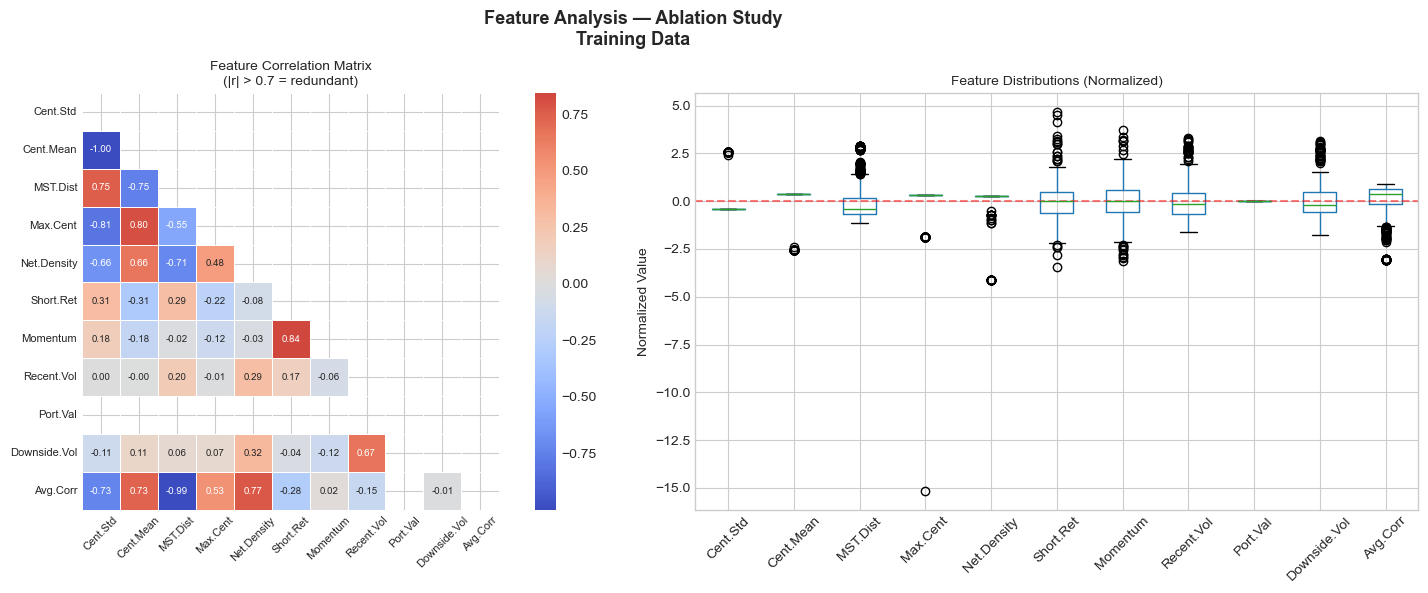


High-correlation pairs (|r| > 0.6):
  Cent.Std <-> Cent.Mean: r = -1.000
  Cent.Std <-> MST.Dist: r = 0.752
  Cent.Std <-> Max.Cent: r = -0.805
  Cent.Std <-> Net.Density: r = -0.657
  Cent.Std <-> Avg.Corr: r = -0.731
  Cent.Mean <-> MST.Dist: r = -0.752
  Cent.Mean <-> Max.Cent: r = 0.805
  Cent.Mean <-> Net.Density: r = 0.657
  Cent.Mean <-> Avg.Corr: r = 0.731
  MST.Dist <-> Net.Density: r = -0.714
  MST.Dist <-> Avg.Corr: r = -0.991
  Net.Density <-> Avg.Corr: r = 0.774
  Short.Ret <-> Momentum: r = 0.843
  Recent.Vol <-> Downside.Vol: r = 0.665


In [79]:
print('=== Phase 4: Global Precompute Cache ===')
print(f'Menghitung cache untuk {len(ret_train) - SET_WINDOW} windows...')
print('(Proses ini hanya berjalan SEKALI untuk semua config)')

# ── Satu global cache untuk semua config ──────────────────────────────────────
# Simpan: corr_f, cent_vec, cov_f, mu, sigma — semua yang dibutuhkan config mana pun
GLOBAL_CACHE = {}   # key: step_idx → dict berisi semua data mentah

for i in range(SET_WINDOW, len(ret_train)):
    win   = ret_train.iloc[i - SET_WINDOW : i]
    T, N  = win.shape
    mu    = win.mean().values
    sigma = win.std().values
    corr_f    = apply_rmt_filter(win)
    mst, cent_vec = _build_mst_centrality(N, corr_f)        # sekali per window
    mst_dist  = sum(d['weight'] for _, _, d in mst.edges(data=True))
    cov_f     = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0

    # Raw network features (full 5D)
    nw_feat_full = np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32)

    GLOBAL_CACHE[i] = {
        'corr_f'       : corr_f,
        'cent_vec'     : cent_vec,
        'cov_f'        : cov_f,
        'mu'           : mu,
        'sigma'        : sigma,
        'nw_feat_full' : nw_feat_full,   # full 5D, siap di-slice per config
    }

print(f'Global cache selesai: {len(GLOBAL_CACHE)} windows cached.')
print()

# ── Build per-config obs_cache & opt_cache dari global cache ─────────────────
def build_caches_from_global(config, global_cache):
    """Buat obs_cache & opt_cache untuk satu config tanpa recompute RMT/MST."""
    obs_cache, opt_cache = {}, {}
    for i, data in global_cache.items():
        nw_feat = data['nw_feat_full'].copy()
        if 'drop_nw_idx' in config:
            nw_feat = np.delete(nw_feat, config['drop_nw_idx'])
        parts = []
        if config['use_network']: parts.append(nw_feat)
        if config['use_market']:  parts.append(np.array([0., 0., 0., 0.], dtype=np.float32))
        if config['extra_features']: parts.append(np.zeros(len(config['extra_features']), dtype=np.float32))
        obs = np.concatenate(parts) if parts else np.array([0.], dtype=np.float32)
        obs_cache[i] = np.nan_to_num(obs)
        opt_cache[i] = (data['cov_f'], data['cent_vec'], data['mu'])
    return obs_cache, opt_cache

print('build_caches_from_global() siap digunakan.')
print('Estimasi speedup Phase 7: ~8x lebih cepat (tidak ada lagi RMT+MST per config).')

# ── Feature Correlation Analysis menggunakan data dari global cache ───────────
# OPT-FIX 4: Tidak loop ulang — pakai data yang sudah ada di GLOBAL_CACHE
# Tambahkan market features dan extra features on-the-fly

feat_names = [
    'Cent.Std', 'Cent.Mean', 'MST.Dist', 'Max.Cent', 'Net.Density',
    'Short.Ret', 'Momentum', 'Recent.Vol', 'Port.Val',
    'Downside.Vol', 'Avg.Corr'
]

all_features = []
for i in sorted(GLOBAL_CACHE.keys()):
    win = ret_train.iloc[i - SET_WINDOW : i]
    cache = GLOBAL_CACHE[i]
    nw  = cache['nw_feat_full']
    mkt = compute_market_features(win)
    # Downside vol dari raw returns
    ret_flat = win.values.flatten()
    neg = ret_flat[ret_flat < 0]
    dv = np.std(neg) * np.sqrt(252) * 10 if len(neg) > 0 else 0.0
    # Avg corr dari corr_f yang sudah ada
    upper_tri = cache['corr_f'][np.triu_indices(cache['corr_f'].shape[0], k=1)]
    avg_corr = float(np.mean(np.abs(upper_tri)))
    all_features.append(np.concatenate([nw, mkt, [dv, avg_corr]]))

df_feat = pd.DataFrame(all_features, columns=feat_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Analysis — Ablation Study\nTraining Data', fontsize=13, fontweight='bold')

ax1 = axes[0]
corr_matrix = df_feat.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax1, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5, annot_kws={'size': 7})
ax1.set_title('Feature Correlation Matrix\n(|r| > 0.7 = redundant)', fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)

ax2 = axes[1]
df_normalized = (df_feat - df_feat.mean()) / (df_feat.std() + 1e-8)
df_normalized.boxplot(ax=ax2, rot=45, fontsize=10)
ax2.set_title('Feature Distributions (Normalized)', fontsize=10)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Normalized Value')

plt.tight_layout()
plt.savefig('ablation_results_4metrics/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nHigh-correlation pairs (|r| > 0.6):')
found = False
for i in range(len(feat_names)):
    for j in range(i + 1, len(feat_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f'  {feat_names[i]} <-> {feat_names[j]}: r = {r:.3f}')
            found = True
if not found:
    print('  (Tidak ada pasangan dengan |r| > 0.6)')

## Phase 5: Ablation Environment

Reward menggunakan **Calmar Ratio** berbasis rolling window.

In [80]:
class AblationPortfolioEnv(gym.Env):
    """
    Environment untuk ablation study.
    Reward: Calmar Ratio (Return / |MaxDD|), rolling window.
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 config, window_size=30, gamma_center=1.0):
        super().__init__()
        self.data            = returns_data
        self.obs_cache       = obs_cache
        self.opt_cache       = opt_cache
        self.config          = config
        self.window_size     = window_size
        self.gamma_center    = gamma_center
        self.current_step    = window_size
        self.port_val        = 1.0
        self.peak_val        = 1.0
        self._returns_buffer = []
        self._reward_window  = REWARD_WINDOW
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0

        obs_dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(obs_dim,), dtype=np.float32)

    def _get_obs(self):
        obs = self.obs_cache[self.current_step].copy()
        if self.config['use_market']:
            offset = 5 if self.config['use_network'] else 0
            port_val_idx = offset + 3
            if port_val_idx < len(obs):
                obs[port_val_idx] = self.port_val - 1.0
        return obs

    def _normalize_reward(self, r):
        """Online reward normalization (Welford's algorithm)."""
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return float(np.clip(r / std, -10.0, 10.0))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = self.window_size
        self.port_val        = 1.0
        self.peak_val        = 1.0
        self._returns_buffer = []
        self._rew_mean       = 0.0
        self._rew_M2         = 0.0
        self._rew_count      = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w        = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)

        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > self._reward_window:
            self._returns_buffer.pop(0)

        arr = np.array(self._returns_buffer)
        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            drawdown, _ = _compute_drawdown(arr)
            max_dd      = drawdown.min()
            ann_ret     = calculate_annualized_return(arr)
            if np.isnan(ann_ret):
                ann_ret = arr.mean() * 252
            denominator = abs(max_dd) if abs(max_dd) > 1e-8 else 1e-8
            calmar      = ann_ret / denominator
            raw_reward  = float(np.clip(calmar, -10.0, 10.0))

        reward = self._normalize_reward(raw_reward)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, reward, done, False, {}


print('AblationPortfolioEnv defined.')

AblationPortfolioEnv defined.


## Phase 6: Backtest Engine & Strategy Classes

> **OPT-FIX 6:** `run_backtest` untuk SAC strategies menggunakan `fast_centrality_weights` dari cache, bukan `get_centrality_weights` (yang menghitung ulang RMT+MST setiap rebalance).

In [81]:
class AblationStrategy:
    def __init__(self, name, model_path, config, gamma_center=1.0, global_cache=None):
        self.name         = name
        self.config       = config
        self.gamma_center = gamma_center
        self.global_cache = global_cache  # OPT-FIX 6: untuk fast_centrality_weights
        self.is_static    = config.get('static_gamma') is not None
        if self.is_static:
            self.model      = None
            self.last_gamma = config['static_gamma']
        else:
            self.model      = SAC.load(model_path)
            self.last_gamma = gamma_center

    def compute_weights(self, returns_window, port_val=1.0, step_idx=None):
        """
        OPT-FIX 6: Jika step_idx tersedia dan global_cache ada,
        gunakan fast_centrality_weights (tanpa recompute RMT+MST).
        Fallback ke get_centrality_weights hanya jika cache tidak tersedia.
        """
        if self.is_static:
            self.last_gamma = self.config['static_gamma']
        else:
            obs, _, _ = build_observation(returns_window, self.config, port_val=port_val - 1.0)
            action, _ = self.model.predict(obs, deterministic=True)
            self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center

        # Fast path: pakai cache jika tersedia
        if self.global_cache is not None and step_idx is not None and step_idx in self.global_cache:
            c = self.global_cache[step_idx]
            return fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], self.last_gamma)
        # Slow path: fallback (hanya untuk test set yang tidak ada di cache)
        return get_centrality_weights(returns_window, gamma=self.last_gamma)


def run_backtest(strategy, data, window=30, rebalance_freq=7, data_start_offset=0):
    """
    OPT-FIX 6: Teruskan step_idx ke compute_weights agar bisa pakai cache.
    data_start_offset: offset indeks data asli (ret_train mulai dari 0, ret_test dari offset tertentu).
    """
    rets, dates, gamma_history = [], [], []
    current_weights = None
    port_val        = 1.0
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df  = data.iloc[i - window : i]
            global_idx = data_start_offset + i  # indeks di GLOBAL_CACHE
            current_weights = strategy.compute_weights(
                window_df,
                port_val=(1.0 if strategy.is_static else port_val),
                step_idx=global_idx
            )
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            port_val  = port_val * (1 + daily_ret)
            rets.append(daily_ret)
            dates.append(data.index[i])
            gamma_history.append(getattr(strategy, 'last_gamma', 1.0))
    return (pd.Series(rets, index=dates, name=strategy.name),
            pd.Series(gamma_history, index=dates))


print('Backtest engine defined.')
print('OPT-FIX 6: fast_centrality_weights via global_cache aktif.')
def run_backtest_baselines(data, assets, window=30):
    """Simulasi strategi benchmark: Equal-Weight, Buy-and-Hold, Classic Markowitz."""
    n_assets = len(assets)
    dates = data.index[window:]
    
    # 1. Equal-Weight (EW)
    ew_rets = []
    w_ew = np.ones(n_assets) / n_assets
    for i in range(window, len(data)):
        ew_rets.append(np.dot(w_ew, data.iloc[i].values))
        
    # 2. Buy-and-Hold (B&H)
    bh_rets = []
    # Inisialisasi unit (asumsi harga awal = 1)
    units = np.ones(n_assets) / n_assets 
    port_val = 1.0
    for i in range(window, len(data)):
        daily_asset_rets = data.iloc[i].values
        # Update unit value
        asset_vals = units * (1 + daily_asset_rets)
        new_port_val = np.sum(asset_vals)
        bh_rets.append((new_port_val - port_val) / port_val)
        port_val = new_port_val
        units = asset_vals / port_val # normalize units to weights
        
    # 3. Classic Markowitz (Classic-MV) - No SAC, No Centrality
    cmv_rets = []
    for i in range(window, len(data)):
        if (i - window) % 7 == 0:
            win   = data.iloc[i-window:i]
            mu    = win.mean().values
            sigma = win.std().values
            corr  = apply_rmt_filter(win)
            cov   = np.outer(sigma, sigma) * corr + np.eye(n_assets)*1e-8
            # Classic MV: gamma=0 (no centrality penalty)
            w_mv = _solve_weights(cov, np.zeros(n_assets), mu, 0.0, n_assets)
        cmv_rets.append(np.dot(w_mv, data.iloc[i].values))
        
    return {
        'EW'        : pd.Series(ew_rets,  index=dates),
        'B&H'       : pd.Series(bh_rets,  index=dates),
        'Classic-MV': pd.Series(cmv_rets, index=dates)
    }


Backtest engine defined.
OPT-FIX 6: fast_centrality_weights via global_cache aktif.


## Phase 7: Training — Semua Ablation Configs

> **OPT-FIX 1:** `learning_starts=50` (turun dari 200) dan `TRAIN_STEPS=1000` (naik dari 100).  
> Sebelumnya `learning_starts > TRAIN_STEPS` — SAC tidak pernah mulai update sama sekali!

> **OPT-FIX 2:** `build_caches_from_global()` menggantikan `precompute_ablation_data()` — tidak ada lagi RMT+MST per config.

In [82]:
# OPT-FIX 1: learning_starts diperbaiki — harus < TRAIN_STEPS agar SAC mulai belajar
sac_kwargs = {
    'policy'         : 'MlpPolicy',
    'learning_rate'  : 3e-4,
    'buffer_size'    : 50000,
    'batch_size'     : 256,
    'ent_coef'       : 'auto',
    'train_freq'     : 1,
    'gradient_steps' : 1,
    'learning_starts': 50,    # OPT-FIX 1: 200 → 50 (harus < TRAIN_STEPS=1000)
    'tau'            : 0.005,
    'gamma'          : 0.99,
}

trained_model_paths = {}

sep = '=' * 60
for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\n{sep}')
    print(f'Experiment: {exp_id} | obs_dim={get_obs_dim(config)}')

    # OPT-FIX 2: Bangun cache dari global_cache — tidak recompute RMT+MST
    obs_cache, opt_cache = build_caches_from_global(config, GLOBAL_CACHE)
    print(f'  Cache built from global (no RMT/MST recompute).')

    for seed in SEEDS:
        if config.get('static_gamma') is not None:
            if seed == SEEDS[0]:
                print(f'  Static benchmark {exp_id} — tidak perlu training.')
            trained_model_paths[(exp_id, seed)] = 'static'
            continue

        print(f'  Training seed={seed} | TRAIN_STEPS={TRAIN_STEPS} | learning_starts=50...')
        env = AblationPortfolioEnv(
            ret_train, obs_cache, opt_cache, config,
            window_size=SET_WINDOW, gamma_center=GAMMA_CENTER,
        )
        model = SAC(env=env, seed=seed, verbose=0, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model_name = f'ablation_{exp_id}_seed{seed}'
        model.save(model_name)
        trained_model_paths[(exp_id, seed)] = model_name
        print(f'    Saved: {model_name}.zip')

print('\n=== Semua model ablation selesai dilatih ===')

Output()


Experiment: Comp_Static_Gamma0 | obs_dim=5
  Cache built from global (no RMT/MST recompute).
  Static benchmark Comp_Static_Gamma0 — tidak perlu training.

Experiment: Comp_Static_Gamma1 | obs_dim=5
  Cache built from global (no RMT/MST recompute).
  Static benchmark Comp_Static_Gamma1 — tidak perlu training.

Experiment: Comp_Static_Gamma2 | obs_dim=5
  Cache built from global (no RMT/MST recompute).
  Static benchmark Comp_Static_Gamma2 — tidak perlu training.

Experiment: E2_NoMarket | obs_dim=5
  Cache built from global (no RMT/MST recompute).
  Training seed=42 | TRAIN_STEPS=500 | learning_starts=50...


Output()

    Saved: ablation_E2_NoMarket_seed42.zip

Experiment: E2_drop_CentStd | obs_dim=4
  Cache built from global (no RMT/MST recompute).
  Training seed=42 | TRAIN_STEPS=500 | learning_starts=50...


Output()

...

Output()

    Saved: ablation_E2_drop_MSTDist_seed42.zip

Experiment: E2_drop_MaxCent | obs_dim=4
  Cache built from global (no RMT/MST recompute).
  Training seed=42 | TRAIN_STEPS=500 | learning_starts=50...


Output()

    Saved: ablation_E2_drop_MaxCent_seed42.zip

Experiment: E2_drop_NetDens | obs_dim=4
  Cache built from global (no RMT/MST recompute).
  Training seed=42 | TRAIN_STEPS=500 | learning_starts=50...


    Saved: ablation_E2_drop_NetDens_seed42.zip

=== Semua model ablation selesai dilatih ===


## Phase 8: Backtest — Training & Testing Data

> **OPT-FIX 6:** Strategy menerima `global_cache` dan `data_start_offset` agar rebalance backtest bisa pakai cache saat di training data.

In [83]:
ablation_results = {}

# Hitung offset test: berapa baris ret_train sebelum ret_test
# GLOBAL_CACHE key adalah indeks dari ret_train (0-based dari seluruh dataset)
# ret_test dimulai dari baris setelah ret_train di dataset asli
# Tapi karena GLOBAL_CACHE hanya di-build untuk ret_train, test set akan fallback ke slow path
# (compute_weights dengan get_centrality_weights) — masih lebih cepat karena training tidak diulang

for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\nBacktest: {exp_id}')
    ablation_results[exp_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        model_path = trained_model_paths[(exp_id, seed)]
        strat = AblationStrategy(
            f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER,
            global_cache=GLOBAL_CACHE  # OPT-FIX 6: pass global cache
        )

        # Training backtest: pakai global_cache (fast path)
        ret_tr, _ = run_backtest(strat, ret_train, SET_WINDOW, SET_REBALANCE,
                                  data_start_offset=0)
        ablation_results[exp_id]['train'][seed] = ret_tr

        # Test backtest: fallback ke slow path (test data tidak di cache)
        ret_te, _ = run_backtest(strat, ret_test, SET_WINDOW, SET_REBALANCE,
                                  data_start_offset=len(ret_train))
        ablation_results[exp_id]['test'][seed] = ret_te

        m_tr = calculate_all_metrics(ret_tr, CVAR_LEVEL)
        m_te = calculate_all_metrics(ret_te, CVAR_LEVEL)
        print(f'  [TRAIN] seed={seed} | Sharpe={m_tr["Sharpe Ratio"]:.3f} | '
              f'Sortino={m_tr["Sortino Ratio"]:.3f} | Calmar={m_tr["Calmar Ratio"]:.3f} | '
              f'CVaR={m_tr["CVaR (95%)"]:.4f}')
        print(f'  [TEST ] seed={seed} | Sharpe={m_te["Sharpe Ratio"]:.3f} | '
              f'Sortino={m_te["Sortino Ratio"]:.3f} | Calmar={m_te["Calmar Ratio"]:.3f} | '
              f'CVaR={m_te["CVaR (95%)"]:.4f}')

# --- Running Baselines ---
print('Running Baselines (EW, B&H, Classic-MV)...')
baselines_train = run_backtest_baselines(ret_train, assets, SET_WINDOW)
baselines_test  = run_backtest_baselines(ret_test, assets, SET_WINDOW)

for b_name in ['EW', 'B&H', 'Classic-MV']:
    ablation_results[b_name] = {'train': {}, 'test': {}}
    for seed in SEEDS:
        ablation_results[b_name]['train'][seed] = baselines_train[b_name]
        ablation_results[b_name]['test'][seed]  = baselines_test[b_name]
    
    m_tr = calculate_all_metrics(baselines_train[b_name], CVAR_LEVEL)
    m_te = calculate_all_metrics(baselines_test[b_name], CVAR_LEVEL)
    print(f'  [BASELINE: {b_name}]')
    print(f'    TRAIN: Sharpe={m_tr["Sharpe Ratio"]:.3f} | Calmar={m_tr["Calmar Ratio"]:.3f}')
    print(f'    TEST : Sharpe={m_te["Sharpe Ratio"]:.3f} | Calmar={m_te["Calmar Ratio"]:.3f}')

print('\nSemua backtest selesai.')


Backtest: Comp_Static_Gamma0
  [TRAIN] seed=42 | Sharpe=-0.394 | Sortino=-0.519 | Calmar=-0.332 | CVaR=0.1197
  [TEST ] seed=42 | Sharpe=-0.142 | Sortino=-0.177 | Calmar=-0.158 | CVaR=0.1006

Backtest: Comp_Static_Gamma1
  [TRAIN] seed=42 | Sharpe=-0.476 | Sortino=-0.641 | Calmar=-0.410 | CVaR=0.1227
  [TEST ] seed=42 | Sharpe=-0.160 | Sortino=-0.205 | Calmar=-0.180 | CVaR=0.0997

Backtest: Comp_Static_Gamma2
  [TRAIN] seed=42 | Sharpe=-0.475 | Sortino=-0.640 | Calmar=-0.409 | CVaR=0.1227
  [TEST ] seed=42 | Sharpe=-0.160 | Sortino=-0.205 | Calmar=-0.180 | CVaR=0.0997

Backtest: E2_NoMarket
  [TRAIN] seed=42 | Sharpe=-0.477 | Sortino=-0.643 | Calmar=-0.411 | CVaR=0.1227
  [TEST ] seed=42 | Sharpe=-0.160 | Sortino=-0.205 | Calmar=-0.180 | CVaR=0.0997

Backtest: E2_drop_CentStd
  [TRAIN] seed=42 | Sharpe=-0.475 | Sortino=-0.640 | Calmar=-0.409 | CVaR=0.1227
  [TEST ] seed=42 | Sharpe=-0.160 | Sortino=-0.205 | Calmar=-0.180 | CVaR=0.0997

Backtest: E2_drop_CentMean
  [TRAIN] seed=42 | Sh

## Phase 9: Agregasi Hasil — 4 Metrik Utama Tesis

In [84]:
def _agg(metrics_list, key):
    """Mean & std satu metrik lintas seed."""
    vals = [m[key] for m in metrics_list]
    return np.nanmean(vals), np.nanstd(vals)


summary_rows = []

ALL_IDS = list(ABLATION_CONFIGS.keys()) + ['EW', 'B&H', 'Classic-MV']
for exp_id in ALL_IDS:
    config = ABLATION_CONFIGS.get(exp_id, {})
    train_metrics = [calculate_all_metrics(ablation_results[exp_id]['train'][s], CVAR_LEVEL) for s in SEEDS]
    test_metrics  = [calculate_all_metrics(ablation_results[exp_id]['test'][s],  CVAR_LEVEL) for s in SEEDS]

    if exp_id in ['EW', 'B&H', 'Classic-MV']:
        feature_desc = ['Standard Baseline']
    elif config.get('static_gamma') is not None:
        feature_desc = [f'Static Gamma {config["static_gamma"]}']
    else:
        feature_desc  = (['Network(5)'] if config['use_network'] else [])
        feature_desc += (['Market(4)']  if config['use_market']  else [])
        feature_desc += config['extra_features']

    row = {
        'Experiment': exp_id,
        'Features'  : ' + '.join(feature_desc),
        'Obs Dim'   : get_obs_dim(config) if exp_id in ABLATION_CONFIGS else 0,
    }

    for period, metrics_list in [('Train', train_metrics), ('Test', test_metrics)]:
        for metric in FOUR_METRICS:
            mean, std = _agg(metrics_list, metric)
            col_key = METRIC_KEY[metric]
            row[f'{col_key}_{period}_Mean'] = mean
            row[f'{col_key}_{period}_Std']  = std

    tr_ann_m, _ = _agg(train_metrics, 'Ann. Return')
    te_ann_m, _ = _agg(test_metrics,  'Ann. Return')
    tr_tot_m, _ = _agg(train_metrics, 'Total Return')
    te_tot_m, _ = _agg(test_metrics,  'Total Return')
    row['AnnRet_Train_Mean'] = tr_ann_m
    row['AnnRet_Test_Mean']  = te_ann_m
    row['TotalRet_Gap']      = tr_tot_m - te_tot_m

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Experiment')
summary_df.to_csv('ablation_results_4metrics/ablation_summary_4metrics.csv')

sep = '=' * 90
print(sep)
print('ABLATION STUDY — 4 METRIK UTAMA TESIS (Testing Period)')
print(sep)
print(f'{"Experiment":<25} {"Sharpe":>10} {"Sortino":>10} {"Calmar":>10} {"CVaR(95%)":>12}')
print('-' * 70)
for exp_id, row in summary_df.iterrows():
    print(f'{exp_id:<25} '
          f'{row["SharpeRatio_Test_Mean"]:>10.4f} '
          f'{row["SortinoRatio_Test_Mean"]:>10.4f} '
          f'{row["CalmarRatio_Test_Mean"]:>10.4f} '
          f'{row["CVaR95pct_Test_Mean"]:>12.5f}')
print(sep)

print('\nRANKING PER METRIK (Testing):')
for metric, col_suffix, ascending in [
    ('Sharpe Ratio',  'SharpeRatio_Test_Mean',  False),
    ('Sortino Ratio', 'SortinoRatio_Test_Mean', False),
    ('Calmar Ratio',  'CalmarRatio_Test_Mean',   False),
    ('CVaR (95%)',    'CVaR95pct_Test_Mean',     True),
]:
    ranked = summary_df.sort_values(col_suffix, ascending=ascending)
    best   = ranked.index[0]
    print(f'  {metric:<14}: #1 {best} = {ranked.loc[best, col_suffix]:.4f}')

ABLATION STUDY — 4 METRIK UTAMA TESIS (Testing Period)
Experiment                    Sharpe    Sortino     Calmar    CVaR(95%)
----------------------------------------------------------------------
Comp_Static_Gamma0           -0.1419    -0.1774    -0.1580      0.10057
Comp_Static_Gamma1           -0.1596    -0.2053    -0.1802      0.09967
Comp_Static_Gamma2           -0.1596    -0.2054    -0.1802      0.09967
E2_NoMarket                  -0.1596    -0.2053    -0.1802      0.09967
E2_drop_CentStd              -0.1596    -0.2053    -0.1802      0.09967
E2_drop_CentMean             -0.1638    -0.2107    -0.1848      0.09966
E2_drop_MSTDist              -0.1596    -0.2053    -0.1802      0.09967
E2_drop_MaxCent              -0.1596    -0.2053    -0.1802      0.09967
E2_drop_NetDens              -0.1596    -0.2053    -0.1802      0.09967
EW                           -0.3452    -0.4352    -0.3890      0.10850
B&H                           0.0297     0.0523     0.0947      0.12318
Classic-MV

## Phase 10: Visualisasi — 4 Metrik Utama

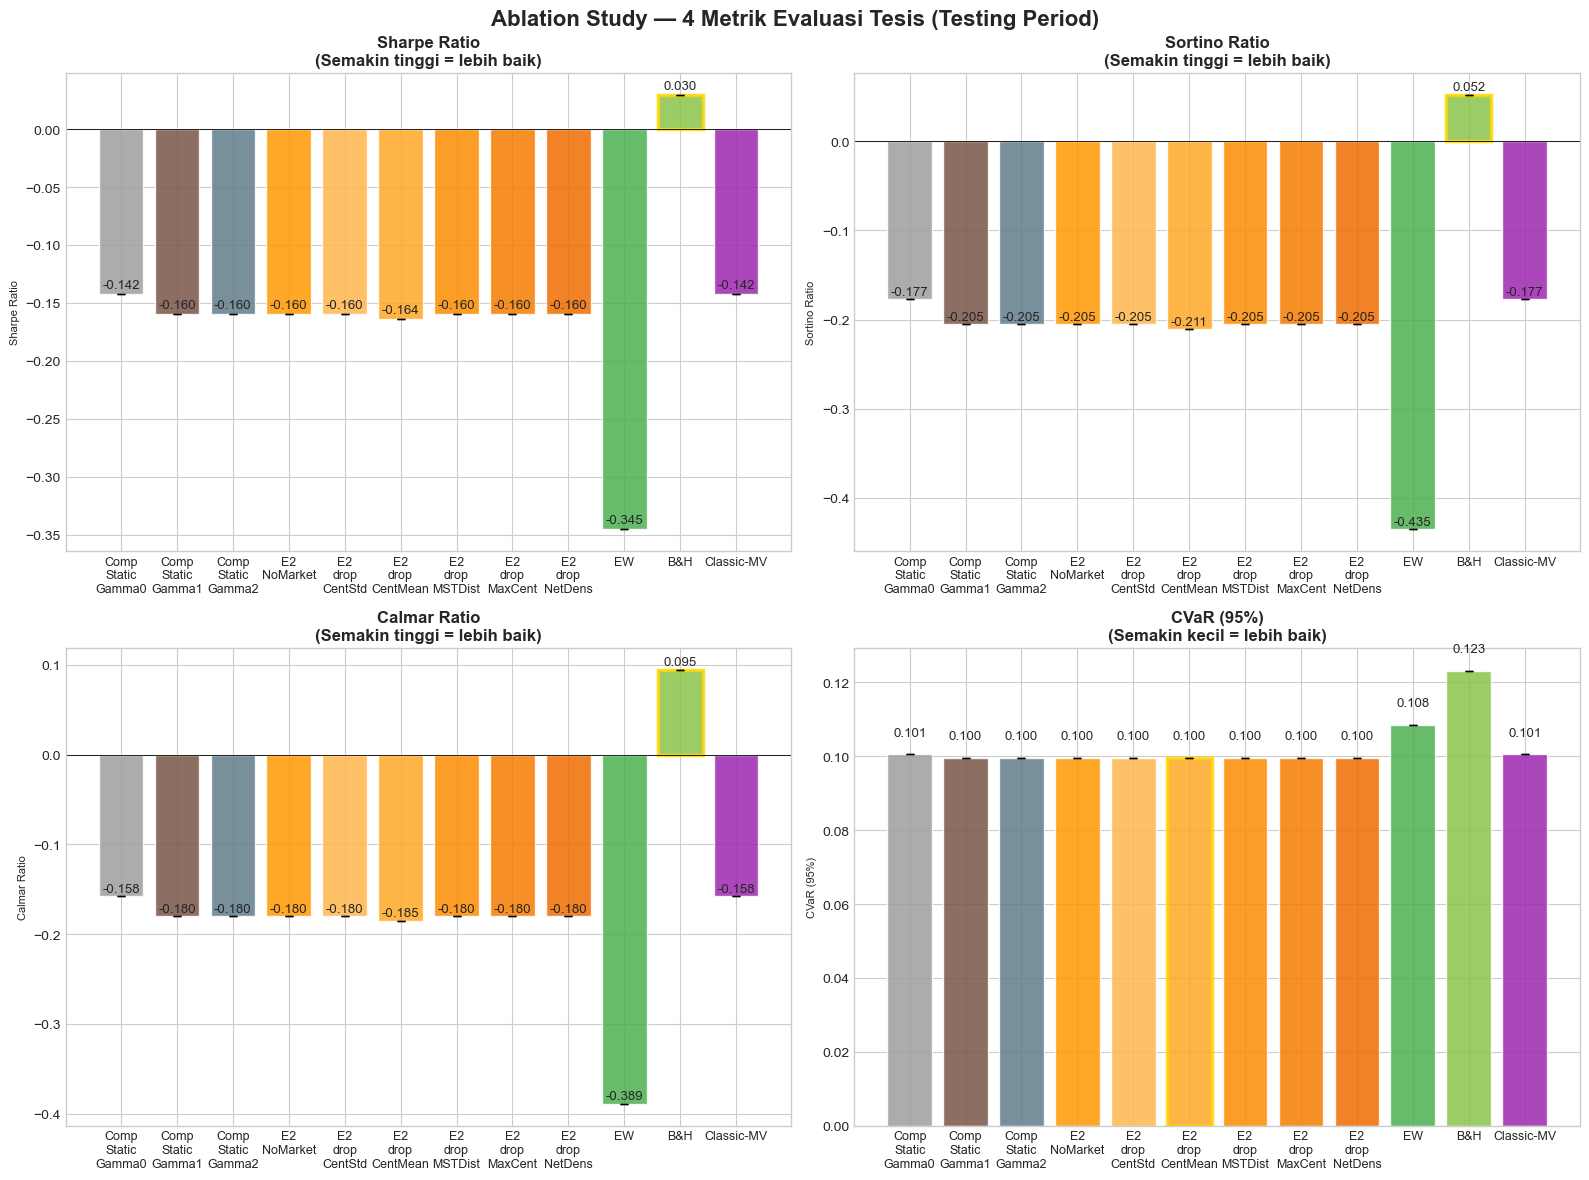

Saved: ablation_results_4metrics/4metrics_bar.png


In [85]:
exp_ids = list(summary_df.index)
colors  = [ABLATION_COLORS[e] for e in exp_ids]

# ── Vis 1: Grouped Bar Chart — 4 Metrik (Testing) ───────────────
metrics_to_plot = [
    ('SharpeRatio_Test_Mean',  'SharpeRatio_Test_Std',  'Sharpe Ratio',  'Semakin tinggi = lebih baik', False),
    ('SortinoRatio_Test_Mean', 'SortinoRatio_Test_Std', 'Sortino Ratio', 'Semakin tinggi = lebih baik', False),
    ('CalmarRatio_Test_Mean',  'CalmarRatio_Test_Std',  'Calmar Ratio',  'Semakin tinggi = lebih baik', False),
    ('CVaR95pct_Test_Mean',    'CVaR95pct_Test_Std',    'CVaR (95%)',    'Semakin kecil = lebih baik',  True),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ablation Study — 4 Metrik Evaluasi Tesis (Testing Period)',
             fontsize=16, fontweight='bold')

for ax, (mean_col, std_col, label, note, lower_better) in zip(axes.flatten(), metrics_to_plot):
    bars, vals, errs = _plot_metric_bars(
        ax, summary_df, exp_ids, colors, mean_col, std_col, label, lower_better,
        short_labels=False
    )
    ax.set_title(f'{label}\n({note})', fontsize=12, fontweight='bold')
    ax.set_xticklabels([e.replace('_', '\n') for e in exp_ids], fontsize=9)
    for bar, v, e in zip(bars, vals, errs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (e if v >= 0 else 0) + 0.005,
                f'{v:.3f}', ha='center', fontsize=9.5)

plt.tight_layout()
plt.savefig('ablation_results_4metrics/4metrics_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_4metrics/4metrics_bar.png')


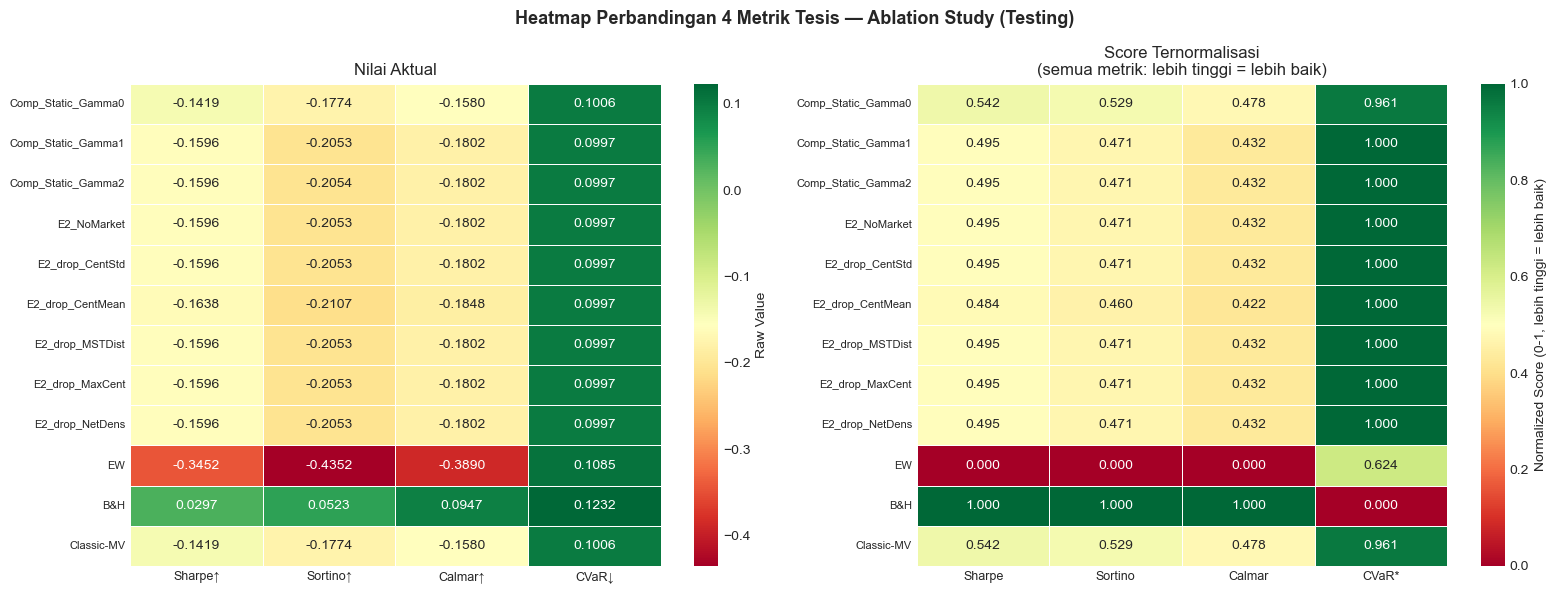

Saved: ablation_results_4metrics/4metrics_heatmap.png


In [86]:
# ── Vis 2: Heatmap 4 Metrik (Testing) ───────────────────────────
heatmap_data, heatmap_norm = _build_heatmap_data(summary_df, exp_ids, 'Test')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Heatmap Perbandingan 4 Metrik Tesis — Ablation Study (Testing)',
             fontsize=13, fontweight='bold')

sns.heatmap(heatmap_data, ax=axes[0], annot=True, fmt='.4f',
            cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Raw Value'})
axes[0].set_title('Nilai Aktual', fontsize=12)
axes[0].set_ylabel('')
axes[0].tick_params(axis='y', labelsize=8, rotation=0)
axes[0].set_xticklabels(['Sharpe↑', 'Sortino↑', 'Calmar↑', 'CVaR↓'], fontsize=9)

sns.heatmap(heatmap_norm, ax=axes[1], annot=True, fmt='.3f',
            cmap='RdYlGn', linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Normalized Score (0-1, lebih tinggi = lebih baik)'})
axes[1].set_title('Score Ternormalisasi\n(semua metrik: lebih tinggi = lebih baik)', fontsize=12)
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=8, rotation=0)
axes[1].set_xticklabels(['Sharpe', 'Sortino', 'Calmar', 'CVaR*'], fontsize=9)

plt.tight_layout()
plt.savefig('ablation_results_4metrics/4metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_4metrics/4metrics_heatmap.png')


KeyError: 'Static Gamma = 0.0'

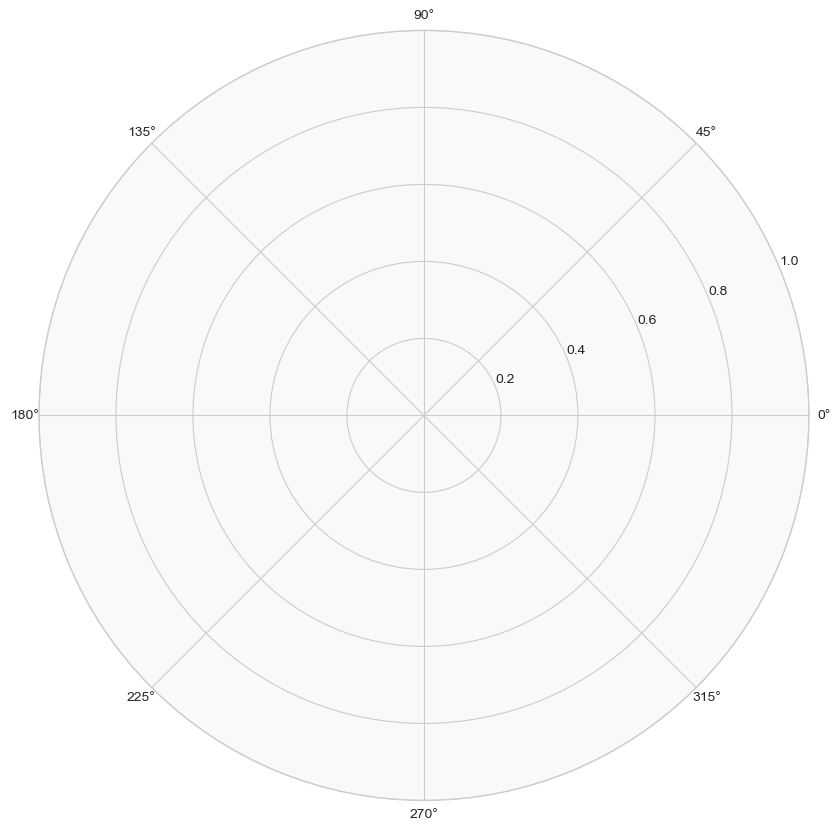

In [87]:
# ── Vis 3: Radar Chart — Profil Risiko (main exps saja) ─────────
radar_metrics = ['Sharpe', 'Sortino', 'Calmar', 'CVaR*']
N_metrics = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#F8F9FA')

for exp_id in MAIN_EXPS:
    values = heatmap_norm.loc[THESIS_LABELS.get(exp_id, exp_id), ['Sharpe', 'Sortino', 'Calmar', 'CVaR(95%)']].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=ABLATION_COLORS[THESIS_LABELS.get(exp_id, exp_id)], label=THESIS_LABELS.get(exp_id, exp_id), alpha=0.8)
    ax.fill(angles, values, alpha=0.08, color=ABLATION_COLORS[THESIS_LABELS.get(exp_id, exp_id)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=10)
ax.set_title('Radar Chart — Profil 4 Metrik Tesis per Eksperimen\n'
             '(Normalized, lebih luar = lebih baik)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('ablation_results_4metrics/4metrics_radar.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_4metrics/4metrics_radar.png')


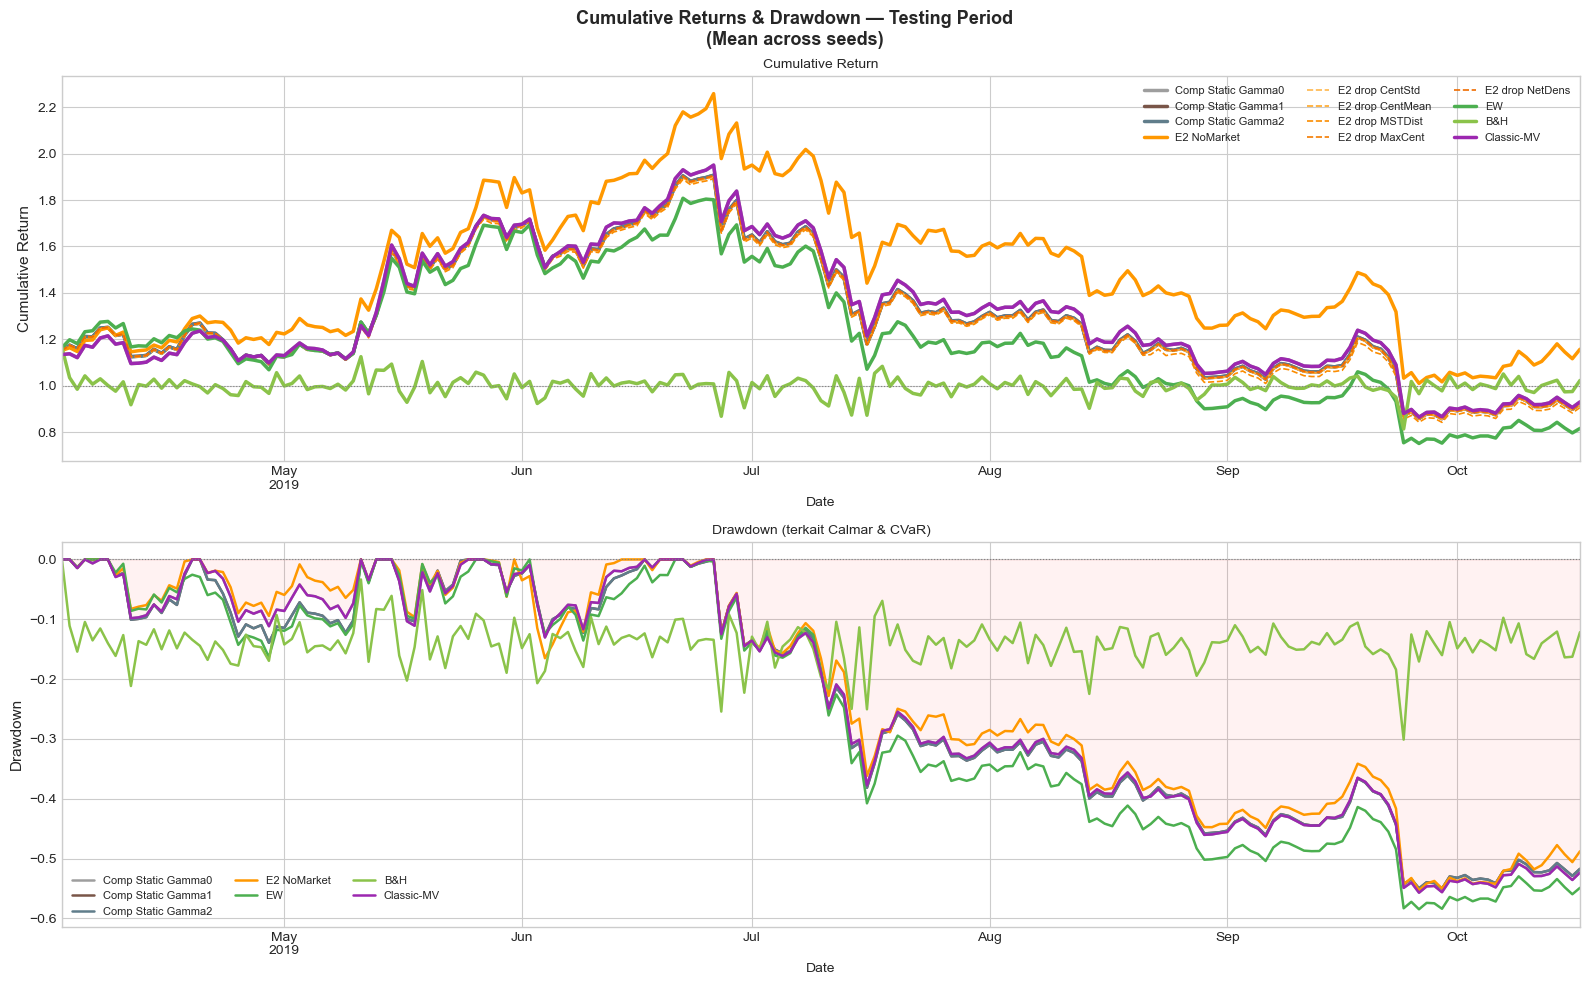

Saved: ablation_results_4metrics/cumret_drawdown.png


In [ ]:
# ── Vis 4: Cumulative Returns + Drawdown (Testing) ───────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
fig.suptitle('Cumulative Returns & Drawdown — Testing Period\n(Mean across seeds)',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
for exp_id in exp_ids:
    cum = (1 + _mean_cumret(ablation_results, exp_id, 'test')).cumprod()
    lw  = 2.5 if exp_id in MAIN_EXPS else 1.2
    ls  = '-'  if exp_id in MAIN_EXPS else '--'
    cum.plot(ax=ax1, label=THESIS_LABELS.get(exp_id, exp_id),
             color=ABLATION_COLORS[exp_id], linewidth=lw, linestyle=ls)
ax1.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax1.set_ylabel('Cumulative Return', fontsize=12)
ax1.set_title('Cumulative Return', fontsize=10)
ax1.legend(fontsize=10, ncol=3)

ax2 = axes[1]
for exp_id in MAIN_EXPS:
    mean_ret = _mean_cumret(ablation_results, exp_id, 'test')
    cum = (1 + mean_ret).cumprod()
    drawdown, _ = _compute_drawdown(mean_ret.values)
    pd.Series(drawdown, index=mean_ret.index).plot(
        ax=ax2, label=THESIS_LABELS.get(exp_id, exp_id),
        color=ABLATION_COLORS[exp_id], linewidth=1.8
    )
ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8)
line0 = ax2.get_lines()[0]
ax2.fill_between(line0.get_xdata(), line0.get_ydata(), 0, alpha=0.05, color='red')
ax2.set_ylabel('Drawdown', fontsize=12)
ax2.set_title('Drawdown (terkait Calmar & CVaR)', fontsize=10)
ax2.legend(fontsize=10, ncol=3)

plt.tight_layout()
plt.savefig('ablation_results_4metrics/cumret_drawdown.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_4metrics/cumret_drawdown.png')


## Phase 11: Final Dashboard Tesis

Dashboard Testing dan Training menggunakan **satu fungsi `plot_dashboard()`** —
menghilangkan duplikasi ~200 baris kode antara Visualisasi 5 dan 6 sebelumnya.

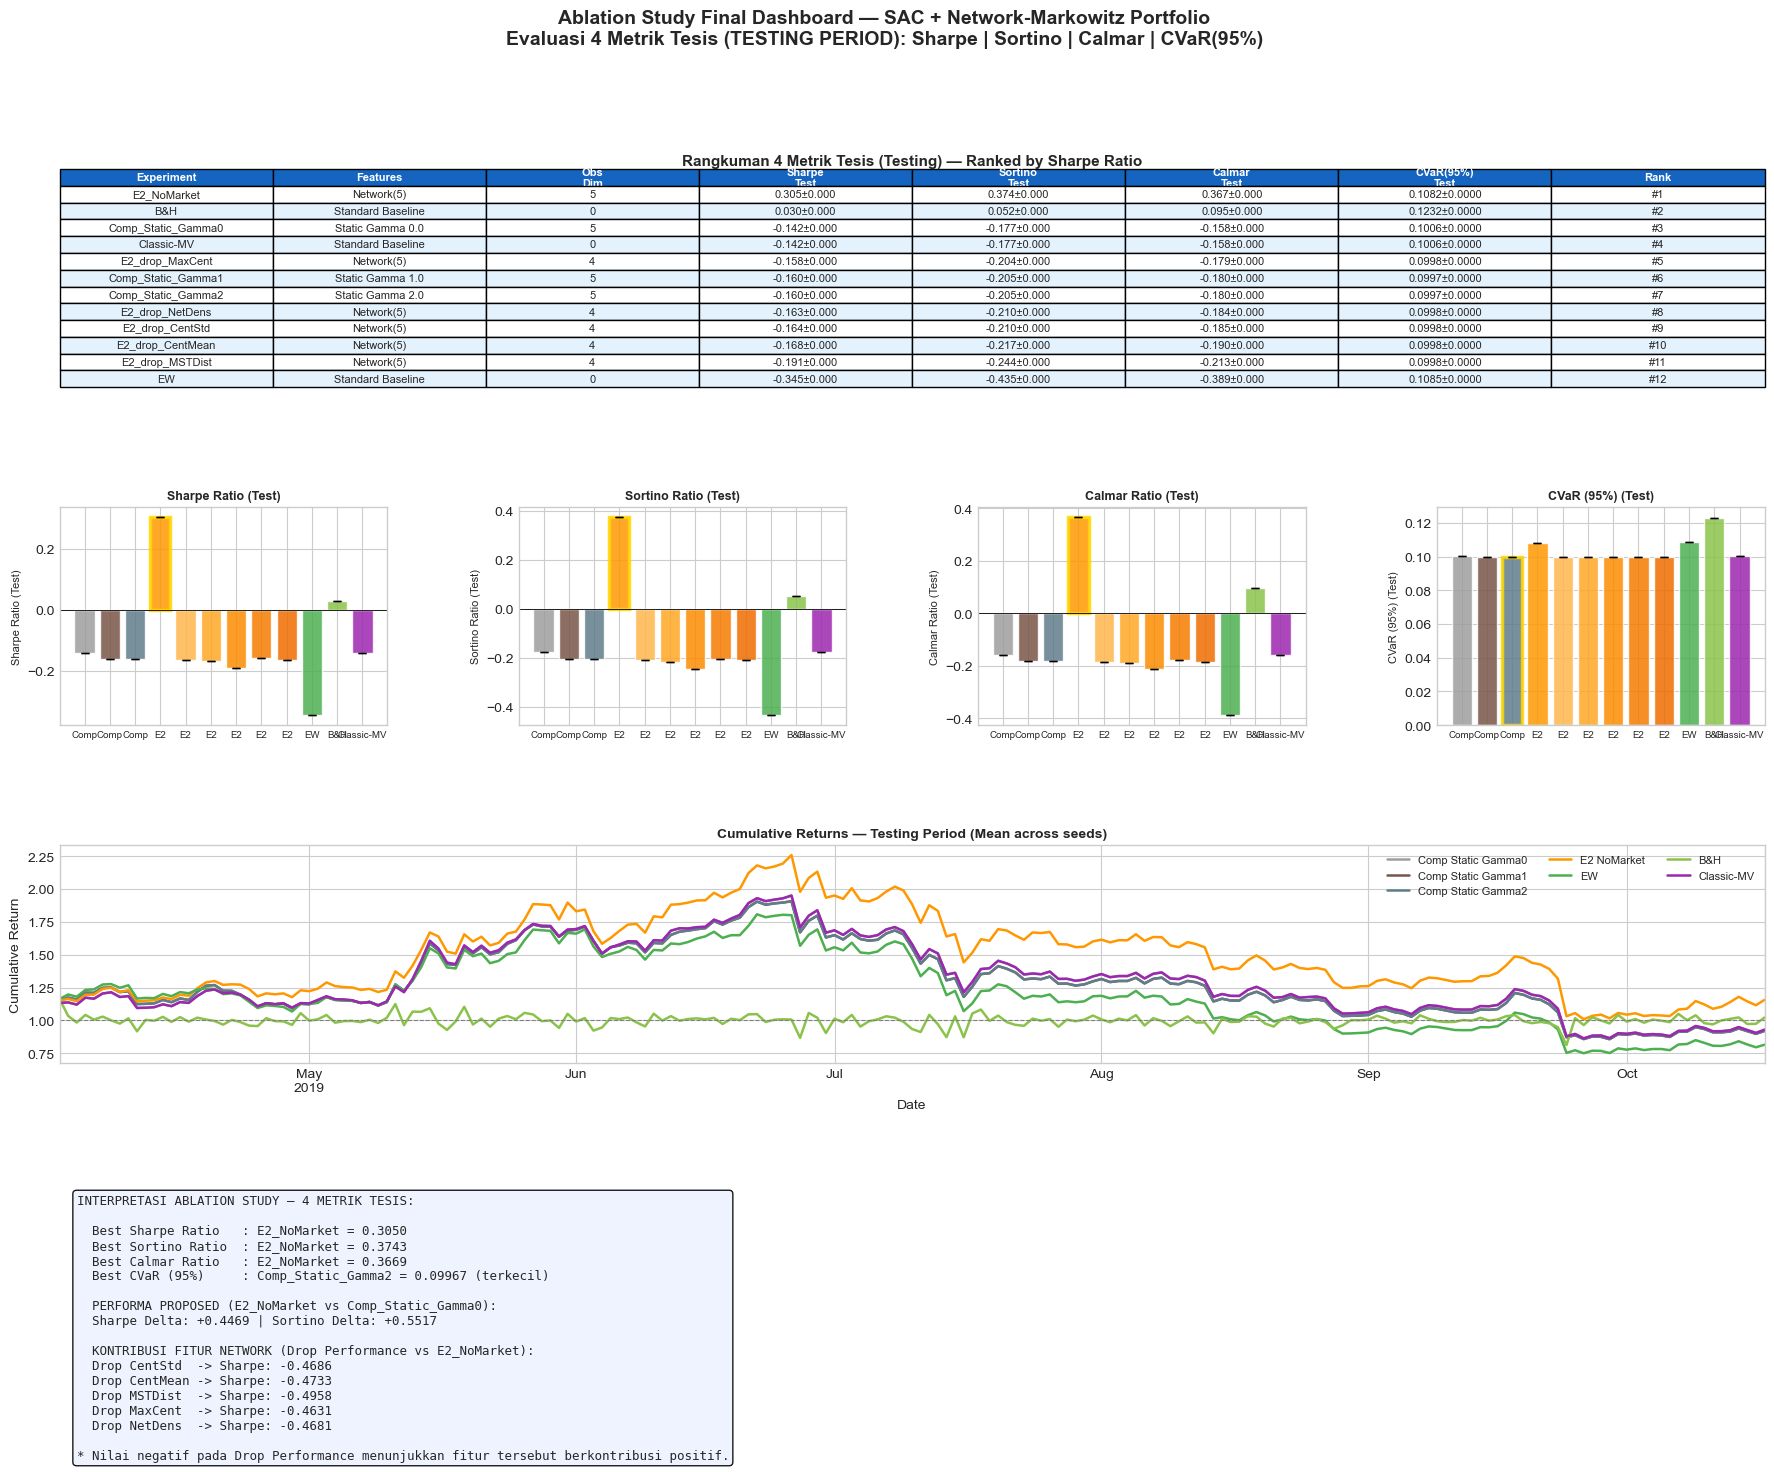

Saved: ablation_results_4metrics/final_dashboard_test_4metrics.png


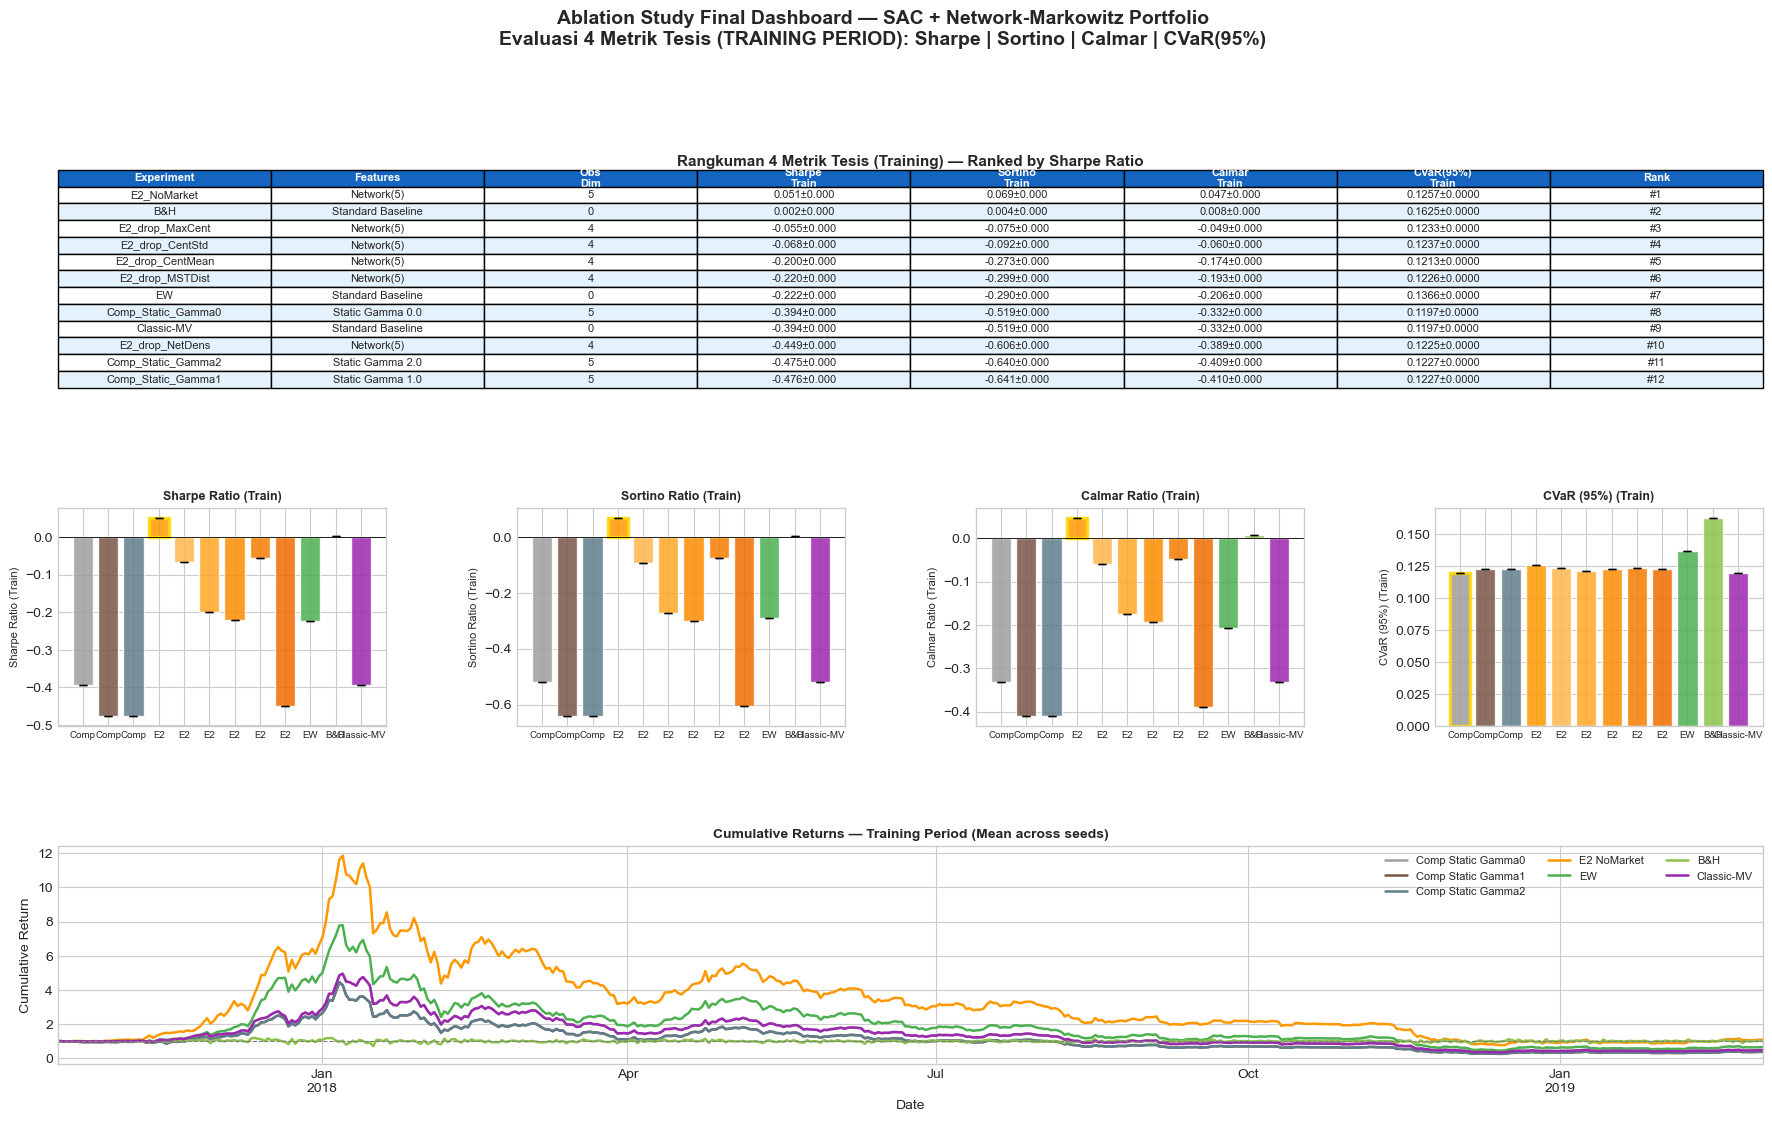

Saved: ablation_results_4metrics/final_dashboard_train_4metrics.png

✅ Ablation Study dengan 4 Metrik Tesis Selesai!
Outputs saved to ablation_results_4metrics/:
  - ablation_summary_4metrics.csv
  - feature_correlation.png
  - 4metrics_bar.png
  - 4metrics_heatmap.png
  - 4metrics_radar.png
  - cumret_drawdown.png
  - final_dashboard_test_4metrics.png
  - final_dashboard_train_4metrics.png


In [ ]:
def plot_dashboard(period, ablation_results, summary_df, exp_ids, colors):
    """
    Render final dashboard tesis untuk satu period ('Test' atau 'Train').
    Menggabungkan Visualisasi 5 & 6 (sebelumnya duplikat ~68%) menjadi satu fungsi.
    """
    period_lower = period.lower()
    period_label = 'Testing' if period == 'Test' else 'Training'

    fig = plt.figure(figsize=(22, 16))
    fig.suptitle(
        f'Ablation Study Final Dashboard — SAC + Network-Markowitz Portfolio\n'
        f'Evaluasi 4 Metrik Tesis ({period_label.upper()} PERIOD): '
        'Sharpe | Sortino | Calmar | CVaR(95%)',
        fontsize=16, fontweight='bold', y=0.98
    )
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.4)

    # ── Panel 1: Summary Table ─────────────────────────────────
    ax_tbl = fig.add_subplot(gs[0, :])
    ax_tbl.axis('off')

    sort_col = f'SharpeRatio_{period}_Mean'
    ranked_df = summary_df.sort_values(sort_col, ascending=False)

    period_short = period[:5]   # 'Test' / 'Train'
    col_labels = [
        'Experiment', 'Features', 'Obs\nDim',
        f'Sharpe\n{period_short}', f'Sortino\n{period_short}',
        f'Calmar\n{period_short}', f'CVaR(95%)\n{period_short}', 'Rank'
    ]
    tbl_data = []
    for rank, (exp_id, row) in enumerate(ranked_df.iterrows(), 1):
        p = period
        tbl_data.append([
            exp_id,
            row['Features'],
            int(row['Obs Dim']),
            f"{row[f'SharpeRatio_{p}_Mean']:.3f}±{row[f'SharpeRatio_{p}_Std']:.3f}",
            f"{row[f'SortinoRatio_{p}_Mean']:.3f}±{row[f'SortinoRatio_{p}_Std']:.3f}",
            f"{row[f'CalmarRatio_{p}_Mean']:.3f}±{row[f'CalmarRatio_{p}_Std']:.3f}",
            f"{row[f'CVaR95pct_{p}_Mean']:.4f}±{row[f'CVaR95pct_{p}_Std']:.4f}",
            f'#{rank}'
        ])

    tbl = ax_tbl.table(cellText=tbl_data, colLabels=col_labels,
                       cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    _style_table(tbl, col_labels, len(tbl_data))
    ax_tbl.set_title(
        f'Rangkuman 4 Metrik Tesis ({period_label}) — Ranked by Sharpe Ratio',
        fontsize=12, fontweight='bold', pad=3
    )

    # ── Panel 2-5: Bar chart per metrik ───────────────────────
    metric_panels = [
        (f'SharpeRatio_{period}_Mean',  f'SharpeRatio_{period}_Std',  f'Sharpe Ratio ({period_short})',  False, gs[1, 0]),
        (f'SortinoRatio_{period}_Mean', f'SortinoRatio_{period}_Std', f'Sortino Ratio ({period_short})', False, gs[1, 1]),
        (f'CalmarRatio_{period}_Mean',  f'CalmarRatio_{period}_Std',  f'Calmar Ratio ({period_short})',  False, gs[1, 2]),
        (f'CVaR95pct_{period}_Mean',    f'CVaR95pct_{period}_Std',    f'CVaR (95%) ({period_short})',    True,  gs[1, 3]),
    ]
    for mean_col, std_col, label, lower_better, gs_pos in metric_panels:
        ax = fig.add_subplot(gs_pos)
        _plot_metric_bars(ax, summary_df, exp_ids, colors, mean_col, std_col, label, lower_better)

    # ── Panel 6: Cumulative Returns ────────────────────────────
    ax_cum = fig.add_subplot(gs[2, :])
    for exp_id in MAIN_EXPS:
        mean_ret = _mean_cumret(ablation_results, exp_id, period_lower)
        (1 + mean_ret).cumprod().plot(
            ax=ax_cum, label=THESIS_LABELS.get(exp_id, exp_id),
            color=ABLATION_COLORS[exp_id], linewidth=1.8
        )
    ax_cum.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax_cum.set_title(
        f'Cumulative Returns — {period_label} Period (Mean across seeds)',
        fontsize=10, fontweight='bold'
    )
    ax_cum.set_ylabel('Cumulative Return')
    ax_cum.legend(fontsize=10, ncol=3)

    # ── Panel 7: Interpretasi Otomatis (Testing only) ─────────
    if period == 'Test':
        ax_interp = fig.add_subplot(gs[3, :])
        ax_interp.axis('off')

        best_sharpe  = summary_df[f'SharpeRatio_Test_Mean'].idxmax()
        best_sortino = summary_df[f'SortinoRatio_Test_Mean'].idxmax()
        best_calmar  = summary_df[f'CalmarRatio_Test_Mean'].idxmax()
        best_cvar    = summary_df[f'CVaR95pct_Test_Mean'].idxmin()

        base = {m: summary_df.loc['Comp_Static_Gamma0', f'{METRIC_KEY[m]}_Test_Mean']
                for m in FOUR_METRICS}

        def delta(exp, m):
            return summary_df.loc[exp, f'{METRIC_KEY[m]}_Test_Mean'] - base[m]

        def drop_delta(exp, m):
            # Perbandingan vs E2_NoMarket (Full Network)
            return (summary_df.loc[exp, f'{METRIC_KEY[m]}_Test_Mean']
                    - summary_df.loc['E2_NoMarket', f'{METRIC_KEY[m]}_Test_Mean'])

        interpretasi = (
            "INTERPRETASI ABLATION STUDY \u2014 4 METRIK TESIS:\n\n"
            f"  Best Sharpe Ratio   : {best_sharpe} = {summary_df.loc[best_sharpe,  'SharpeRatio_Test_Mean']:.4f}\n"
            f"  Best Sortino Ratio  : {best_sortino} = {summary_df.loc[best_sortino, 'SortinoRatio_Test_Mean']:.4f}\n"
            f"  Best Calmar Ratio   : {best_calmar} = {summary_df.loc[best_calmar,  'CalmarRatio_Test_Mean']:.4f}\n"
            f"  Best CVaR (95%)     : {best_cvar} = {summary_df.loc[best_cvar, 'CVaR95pct_Test_Mean']:.5f} (terkecil)\n\n"
            "  PERFORMA PROPOSED (E2_NoMarket vs Comp_Static_Gamma0):\n"
            f"  Sharpe Delta: {delta('E2_NoMarket','Sharpe Ratio'):+.4f} | "
            f"Sortino Delta: {delta('E2_NoMarket','Sortino Ratio'):+.4f}\n\n"
            "  KONTRIBUSI FITUR NETWORK (Drop Performance vs E2_NoMarket):\n"
            f"  Drop CentStd  -> Sharpe: {drop_delta('E2_drop_CentStd', 'Sharpe Ratio'):+.4f}\n"
            f"  Drop CentMean -> Sharpe: {drop_delta('E2_drop_CentMean','Sharpe Ratio'):+.4f}\n"
            f"  Drop MSTDist  -> Sharpe: {drop_delta('E2_drop_MSTDist', 'Sharpe Ratio'):+.4f}\n"
            f"  Drop MaxCent  -> Sharpe: {drop_delta('E2_drop_MaxCent', 'Sharpe Ratio'):+.4f}\n"
            f"  Drop NetDens  -> Sharpe: {drop_delta('E2_drop_NetDens', 'Sharpe Ratio'):+.4f}\n"
            "\n* Nilai negatif pada Drop Performance menunjukkan fitur tersebut berkontribusi positif."
        )
        ax_interp.text(0.01, 0.95, interpretasi, transform=ax_interp.transAxes,
                       fontsize=9, verticalalignment='top', fontfamily='monospace',
                       bbox=dict(boxstyle='round', facecolor='#EEF2FF', alpha=0.9))

    fname = f'ablation_results_4metrics/final_dashboard_{period_lower}_4metrics.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


# ── Render kedua dashboard ───────────────────────────────────────
plot_dashboard('Test',  ablation_results, summary_df, exp_ids, colors)
plot_dashboard('Train', ablation_results, summary_df, exp_ids, colors)

print('\n✅ Ablation Study dengan 4 Metrik Tesis Selesai!')
print('Outputs saved to ablation_results_4metrics/:')
for f in ['ablation_summary_4metrics.csv', 'feature_correlation.png',
          '4metrics_bar.png', '4metrics_heatmap.png', '4metrics_radar.png',
          'cumret_drawdown.png', 'final_dashboard_test_4metrics.png',
          'final_dashboard_train_4metrics.png']:
    print(f'  - {f}')

